In [2]:
from common import *

get(
    "machinable.index",
    "./index",
).__enter__()


machinable.index [df7e33]

In [6]:
_ca1_samplers = get("interface._ca1_samplers")

globus_download(_ca1_samplers)

numprocs=1


In [7]:
_ca1_optimizers = get("interface._ca1_optimizers")

globus_download(_ca1_optimizers)

2025-07-17 20:26:26.684377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-17 20:26:26.705520: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-17 20:26:26.705556: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-17 20:26:26.719609: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-17 20:26:27.789488: W tensorflow/compiler/tf

In [8]:
nadirs = population_nadirs(_ca1_samplers, _ca1_optimizers)

In [9]:
hvs = {}

for p in _ca1_samplers.populations():
    experiments = _ca1_samplers.components.filter(lambda x: p in x.label())
    num_initial = experiments[0].num_initial_samples
    nadir = nadirs[p]
    for experiment in experiments:
        name = experiment.config.dopt_params.initial_method

        hvs.setdefault(p, {})
        
        hv = experiment.norm_hv(nadir)
        hvs[p].setdefault(name + '_sopt', [])
        hvs[p][name  + '_sopt'].append(hv)

        hv = experiment.norm_hv_region(nadir, region=[0, num_initial])
        hvs[p].setdefault(name + "_initial", [])
        hvs[p][name + "_initial"].append(hv)
    
    for experiment in _ca1_optimizers.components.filter(lambda x: p in x.label()):
        optimizer_name = experiment.config.dopt_params.optimizer_name
        hvs[p].setdefault(optimizer_name, [])
        hvs[p][optimizer_name].append(experiment.norm_hv(nadir))

In [10]:
stash("figure2-hvs", hvs)
stash("figure2-nadirs", nadirs)

In [11]:
hvs = restore("figure2-hvs")
nadirs = restore("figure2-nadirs")

## Baseline

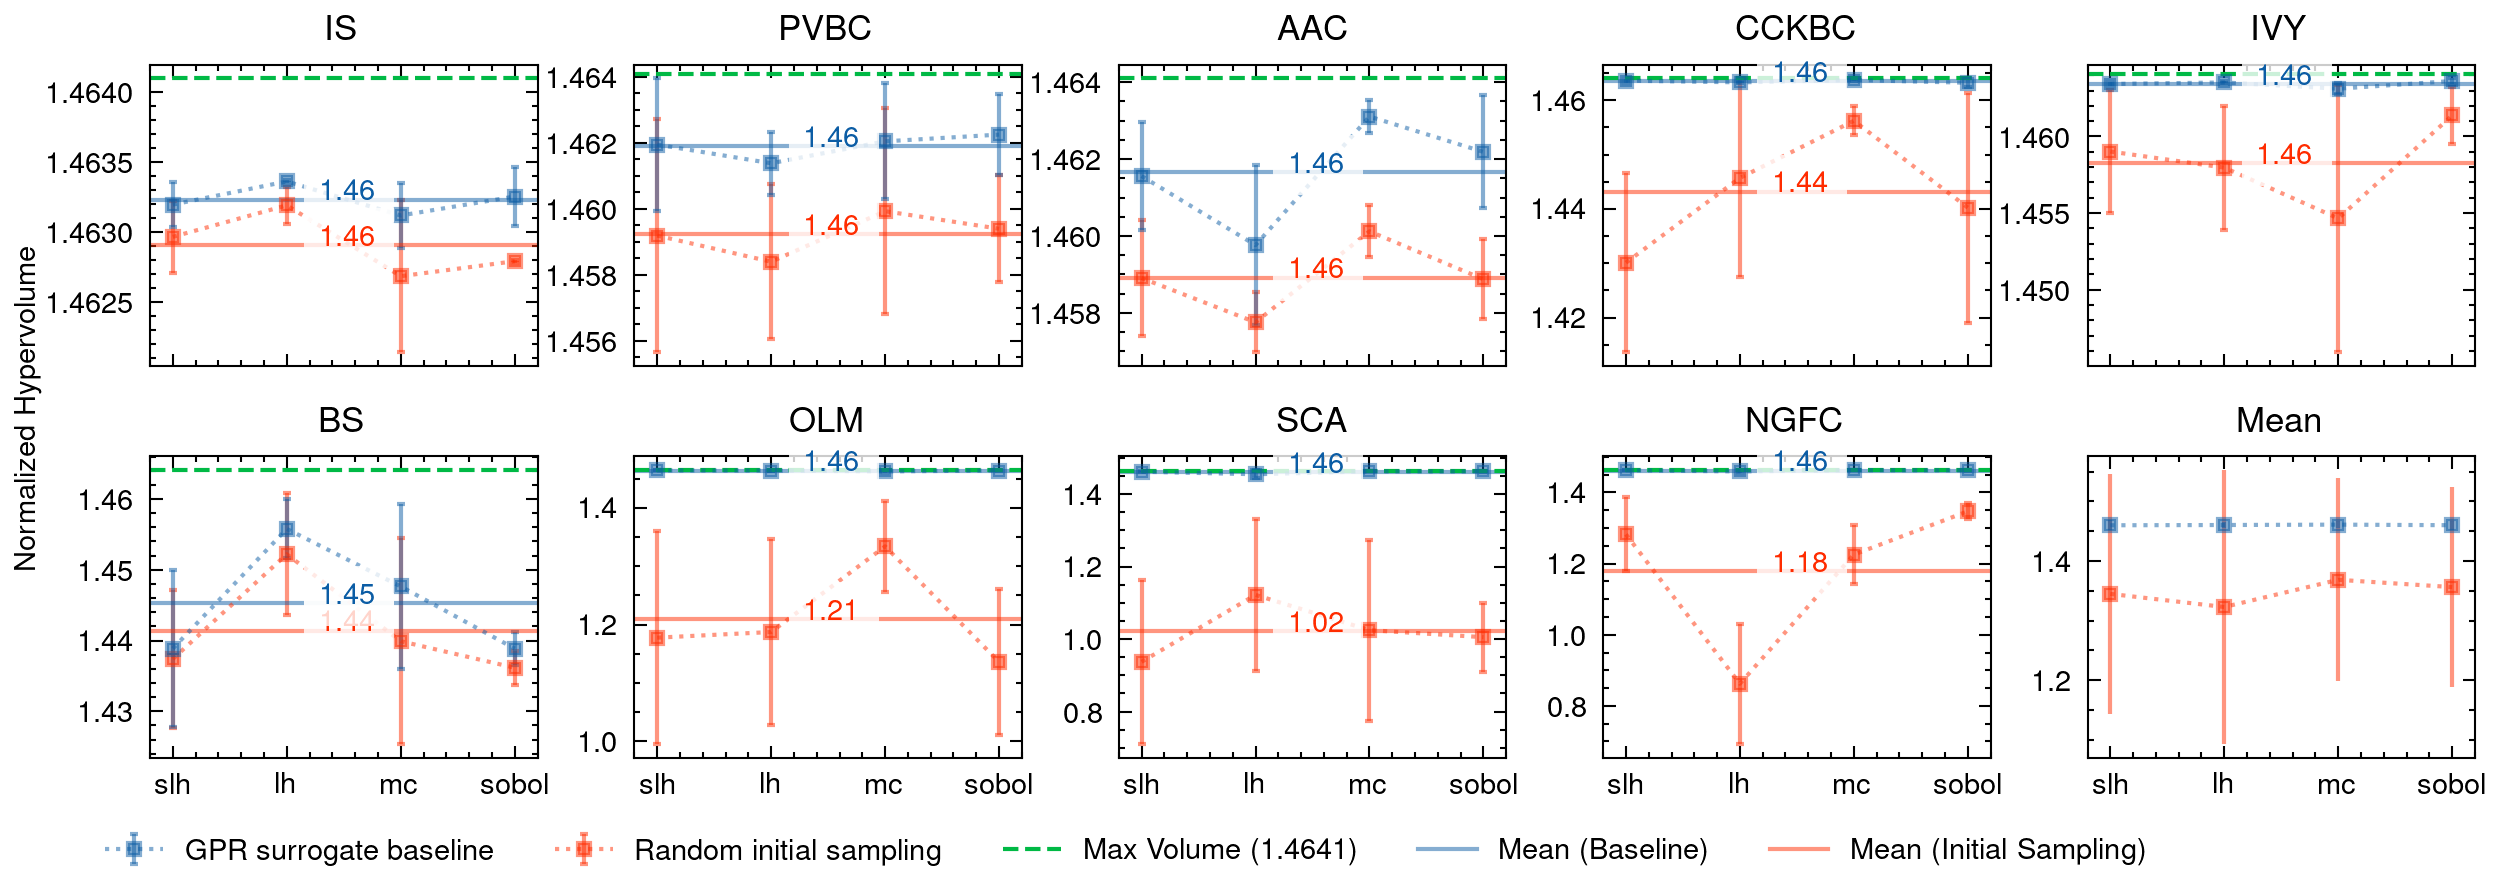

In [12]:
fig, axs = plt.subplots(2, 5, figsize=(10, 3), sharey=False, sharex=True)

c = {0: colors["red"], 1: colors["blue"]}

for ix, (ax, cell_type) in enumerate(
    zip(
        axs.flatten()[:-1],
        ["IS", "PVBC", "AAC", "CCKBC", "IVY", "BS", "OLM", "SCA", "NGFC"],
    )
):
    means_initial = []
    stds_initial = []
    means = []
    stds = []
    labels = []
    means_opt = []
    stds_opt = []
    labels_opt = []
    for name, hv in hvs[cell_type].items():
        if name.endswith("_initial"):
            means_initial.append(np.mean(hv))
            stds_initial.append(np.std(hv))
        elif name.endswith('_sopt'):
            means.append(np.mean(hv))
            stds.append(np.std(hv))
            labels.append(name.replace('_sopt', ''))
        else:
            # optimizers
            means_opt.append(np.mean(hv))
            stds_opt.append(np.std(hv))
            labels_opt.append(name)
    
    # ax.errorbar(
    #     labels_opt,
    #     means_opt,
    #     yerr=stds_opt,
    #     color='black',
    #     #fmt="s:",
    #     alpha=0.5,
    #    # label="GPR surrogate baseline",
    # )

    ax.errorbar(
        labels,
        means_initial,
        yerr=stds_initial,
        color=c[0],
        fmt="s:",
        capsize=1,
        alpha=0.5,
        label="Random initial sampling",
    )
    ax.errorbar(
        labels,
        means,
        yerr=stds,
        color=c[1],
        fmt="s:",
        alpha=0.5,
        capsize=1,
        label="GPR surrogate baseline",
    )

    for i, ms in enumerate([means_initial, means]):
        mean_value = np.mean(ms)
        ax.axhline(
            y=mean_value,
            # xmin=0.3,
            # xmax=1,
            xmin=0, xmax=3,
            color=c[i],
            linestyle="-",
            alpha=0.5,
            label="Mean (Initial Sampling)" if i == 0 else "Mean (Baseline)",
        )
        ax.text(
            1.3, #3.12, #len(labels) + 2,
            mean_value,
            f"{mean_value:.2f}",
            color=c[i],
            #verticalalignment="top",
            #horizontalalignment="center",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none") #if cell_type in ['OLM', 'SCA', 'NGFC', 'IVY', 'CCKBC'] else None,
        )
    ax.set_xlim(-0.2, 4)
    

    ax.axhline(
        y=1.1**4, color=colors["green"], linestyle="--", label=f"Max Volume ({1.1**4:.4f})"
    )
    # if ix < 3:
    #     ax.set_ylim(1.4, 1.1**4 * 1.05)
    # ax.legend()
    ax.set_title(cell_type)  # , y=0.7)

    # ax.set_xticklabels(labels, rotation=45, ha='right')

ax2 = axs[1][-1]
for i, ms in enumerate([means_initial, means]):
    mean_by_sampler = {
        sampler: np.mean(
            [
                models[(sampler + "_initial") if i == 0 else (sampler + '_sopt')]
                for models in hvs.values()
            ]
        )
        for sampler in labels
    }
    std_by_sampler = {
        sampler: np.std(
            [
                models[(sampler + "_initial") if i == 0 else (sampler + '_sopt')]
                for models in hvs.values()
            ]
        )
        for sampler in labels
    }
    ax2.errorbar(
        labels,
        [mean_by_sampler[l] for l in labels],
        yerr=[std_by_sampler[l] for l in labels],
        fmt="s:",
        color=c[i],
        alpha=0.5,
        label="Mean across cells",
    )
    
    ax.set_xlim(-0.2, 3.2)


ax2.set_title("Mean")  # , y=0.7)


# axs[0][0].set_ylabel("Normalized Hypervolume")
# axs[1][0].set_ylabel("Normalized Hypervolume")
fig.text(0.08, 0.5, "Normalized Hypervolume", va="center", rotation="vertical")

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(
    reversed(handles), reversed(labels), ncol=len(labels), bbox_to_anchor=(0.8, 0.05)
)

plt.subplots_adjust(wspace=0.25, hspace=0.3)
plt.show()

In [14]:
stash("figure2/samplers", fig)

## Surrogate accuracy

In [4]:
from models.metrics import compute_metric

metric_names = ['nrmse', 'mape', 'r2', 'spearman']

prediction_metrics = {}
timing_metrics = {}

for model in get('interface._ca1_inference').models():
    data = load_file(f'./figures/data/figure2-inference/{model}.p')

    population, model = model.split('-', 1)

    prediction_metrics.setdefault(population, {})
    timing_metrics.setdefault(population, {})

    prediction_metrics[population][model] = {}
    timing_metrics[population][model] = {
        'cv': [], 'fit': [], 'predict': []
    }

    for epoch in data:
        for metric_name in metric_names:
            for t in ['train', 'test']:
                prediction_metrics[population][model].setdefault(metric_name + '_' + t, [])

                y_true = epoch['y_' + t]
                y_pred = epoch['y_pred_' + t]

                if model.endswith('-c+o'):
                    y_pred = y_pred['objectives']

                prediction_metrics[population][model][metric_name+ '_' + t].append(
                    float(compute_metric(metric_name, y_true, y_pred))
                )

                timing_metrics[population][model]['cv'].append(
                    epoch["t_autoepoch"]
                )
                timing_metrics[population][model]['fit'].append(
                   epoch["t_autofit"]
                )
                timing_metrics[population][model]['predict'].append(
                   epoch['t_y_pred_train']
                )



numprocs=1


2025-07-24 15:44:06.151074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 15:44:06.171565: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 15:44:06.171602: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 15:44:06.184966: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-24 15:44:07.332854: W tensorflow/compiler/tf

In [5]:
stash('figure2-prediction_metrics', prediction_metrics)
stash('figure2-timing_metrics', timing_metrics)

In [6]:
prediction_metrics = restore('figure2-prediction_metrics')
timing_metrics = restore('figure2-timing_metrics')

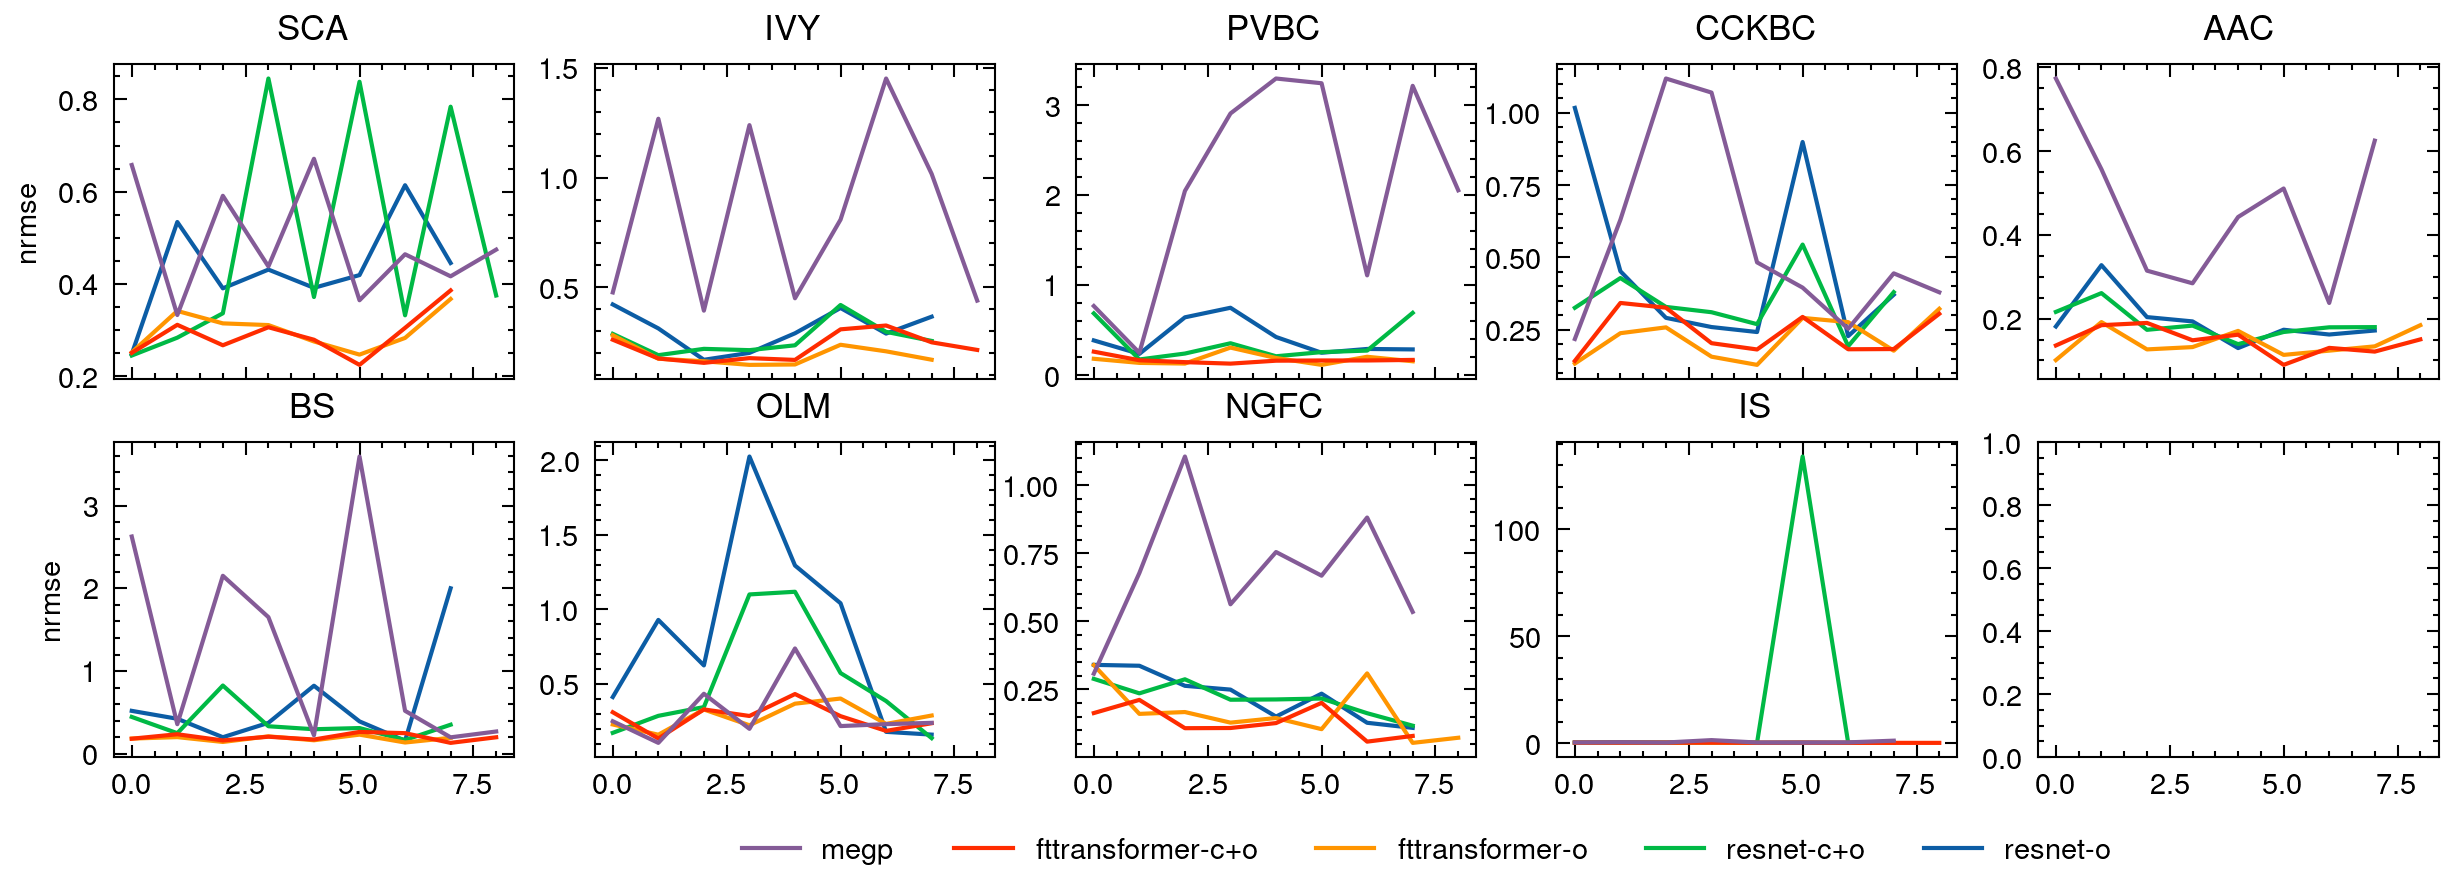

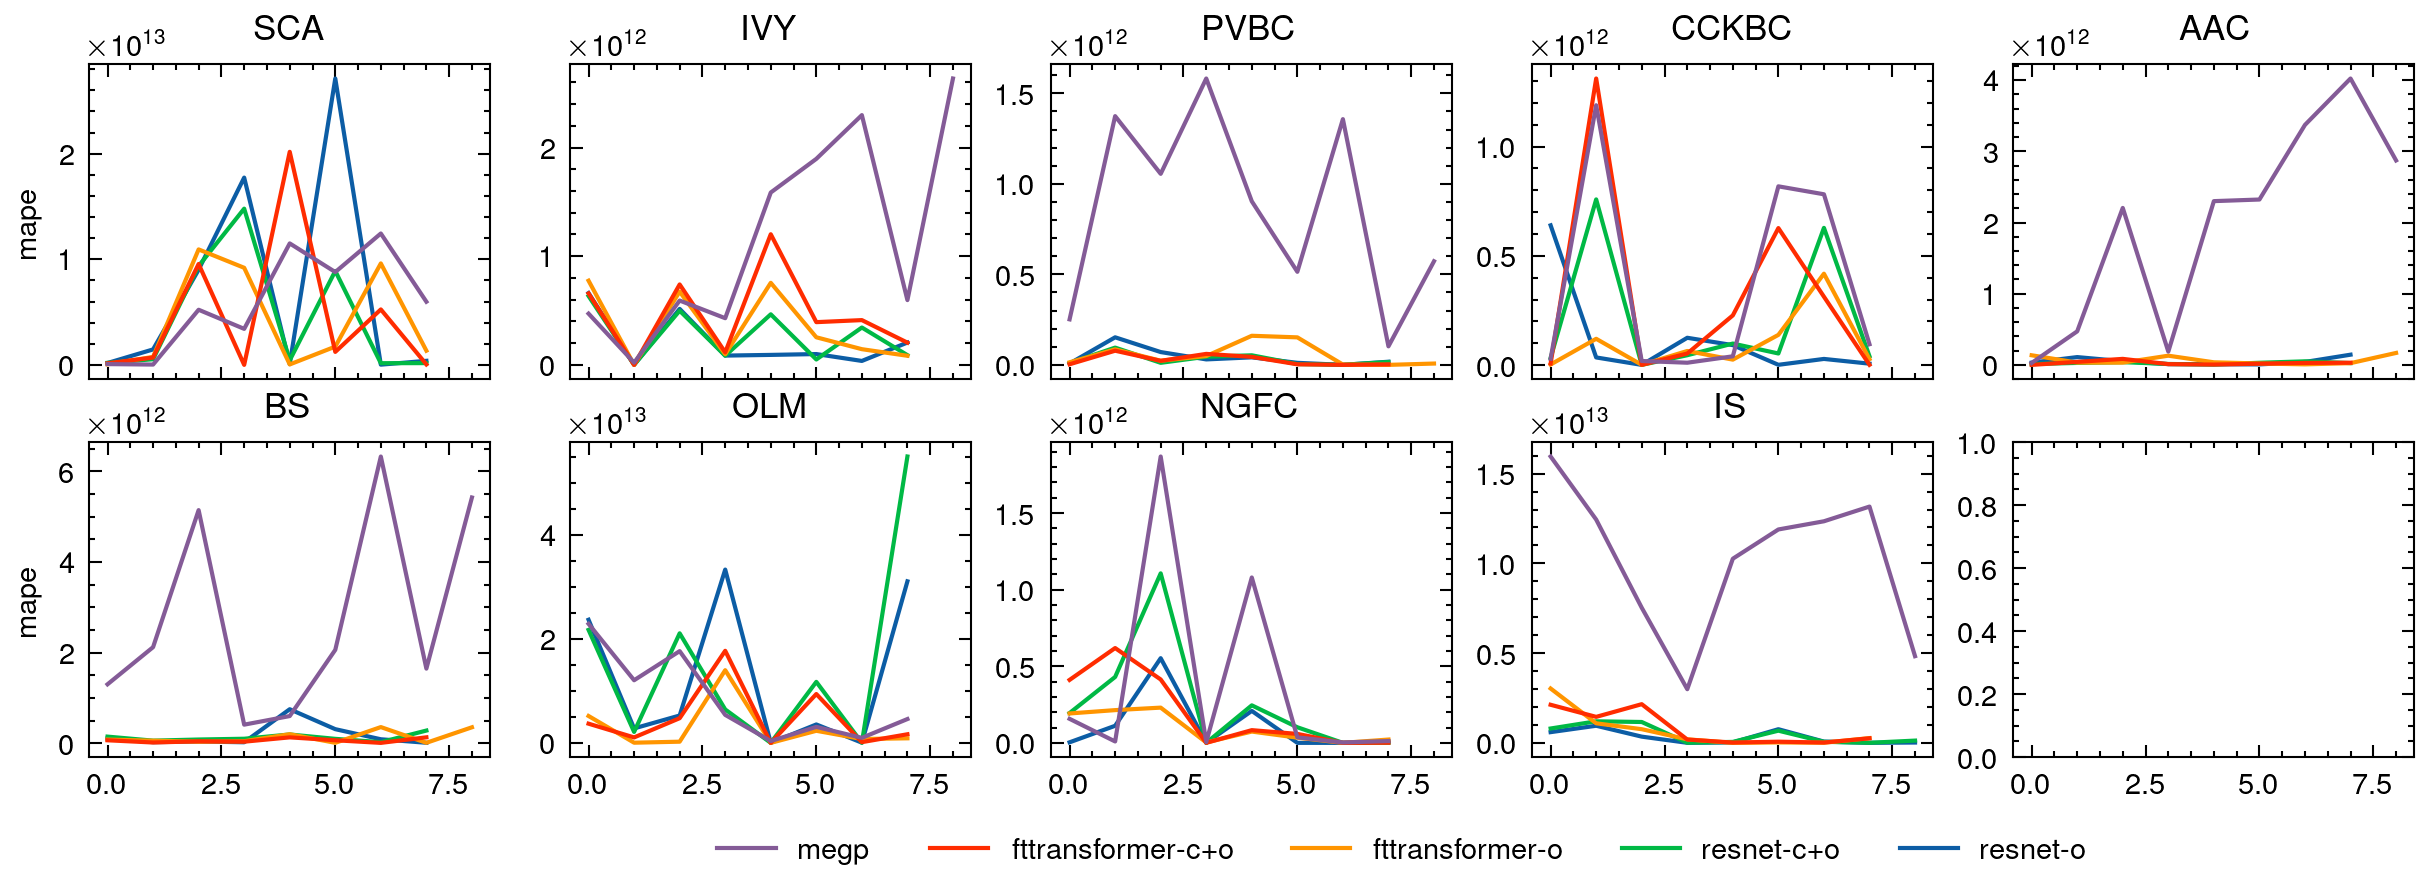

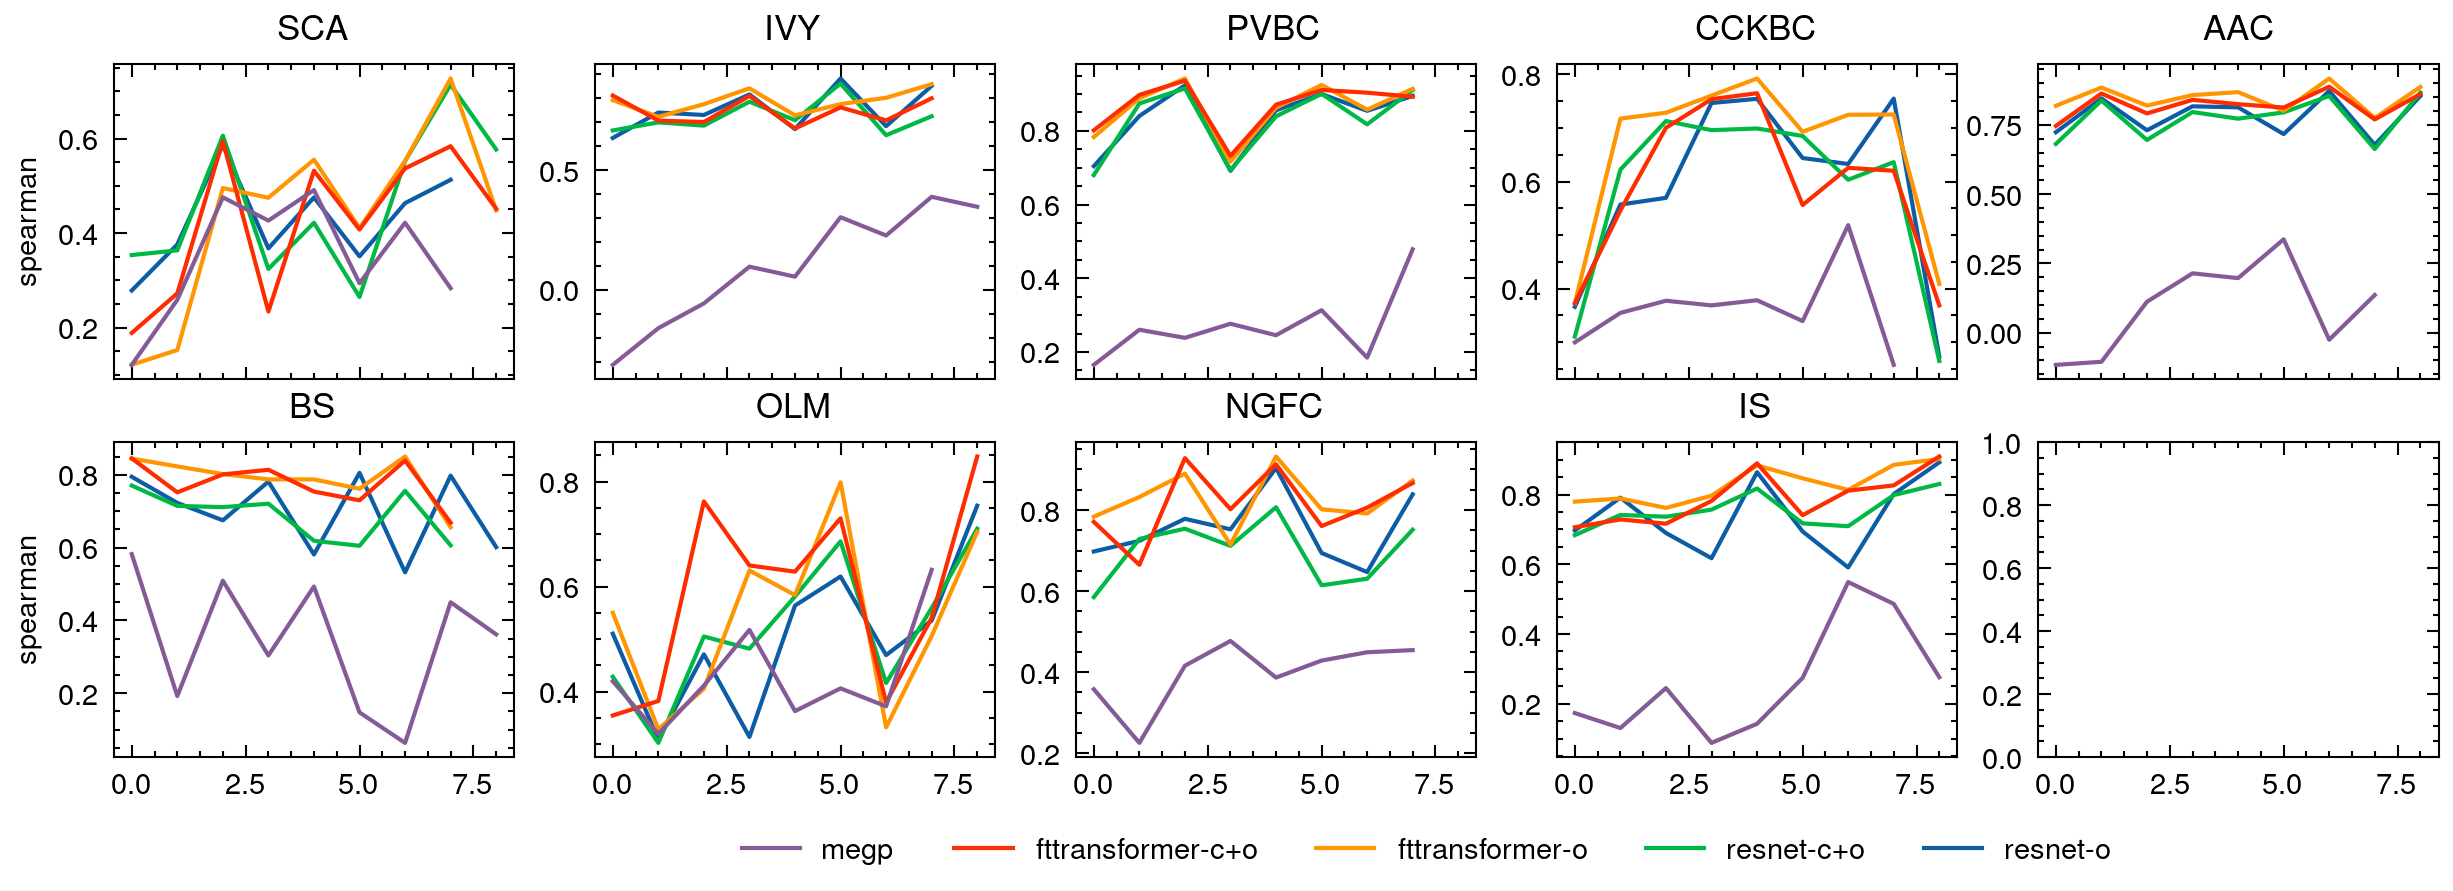

In [7]:
prediction_summary = {}

for metric_name in metrics:
    if metric_name == 'r2':
        continue

    fig, axs = plt.subplots(2, 5, figsize=(10, 3), sharey=False, sharex=True)

    for ix, (cell_type, d) in enumerate(
        prediction_metrics.items()
    ):
        ax = axs.flatten()[ix]
        ax.set_title(cell_type)  # , y=0.7)

        for model, m in d.items():
            y = m[metric_name + '_test']

            # z-score filter outliers
            y_arr = np.array(y)
            z_scores = (y_arr - np.nanmean(y_arr)) / (np.nanstd(y_arr) + 1e-8)
            outlier_mask = np.abs(z_scores) > 2
            y_arr[outlier_mask] = np.nan
            y = y_arr.tolist()

            prediction_summary.setdefault(metric_name, {})
            prediction_summary[metric_name].setdefault(model, [])

            y = np.array(y)
            y = y[~np.isnan(y)]
            prediction_summary[metric_name][model] += y.tolist()

            ax.plot(np.arange(len(y)), y, label=model)

    axs[0][0].set_ylabel(metric_name)
    axs[1][0].set_ylabel(metric_name)

    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(
        reversed(handles), reversed(labels), ncol=len(labels), bbox_to_anchor=(0.8, 0.05)
    )
    
    #plt.subplots_adjust(wspace=0.25, hspace=0.3)
    plt.show()

    

/tmp/ipykernel_1308114/2862308977.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=list(model_dict.keys()), patch_artist=True,  showfliers=False)
/tmp/ipykernel_1308114/2862308977.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=list(model_dict.keys()), patch_artist=True,  showfliers=False)
/tmp/ipykernel_1308114/2862308977.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=list(model_dict.keys()), patch_artist=True,  showfliers=False)


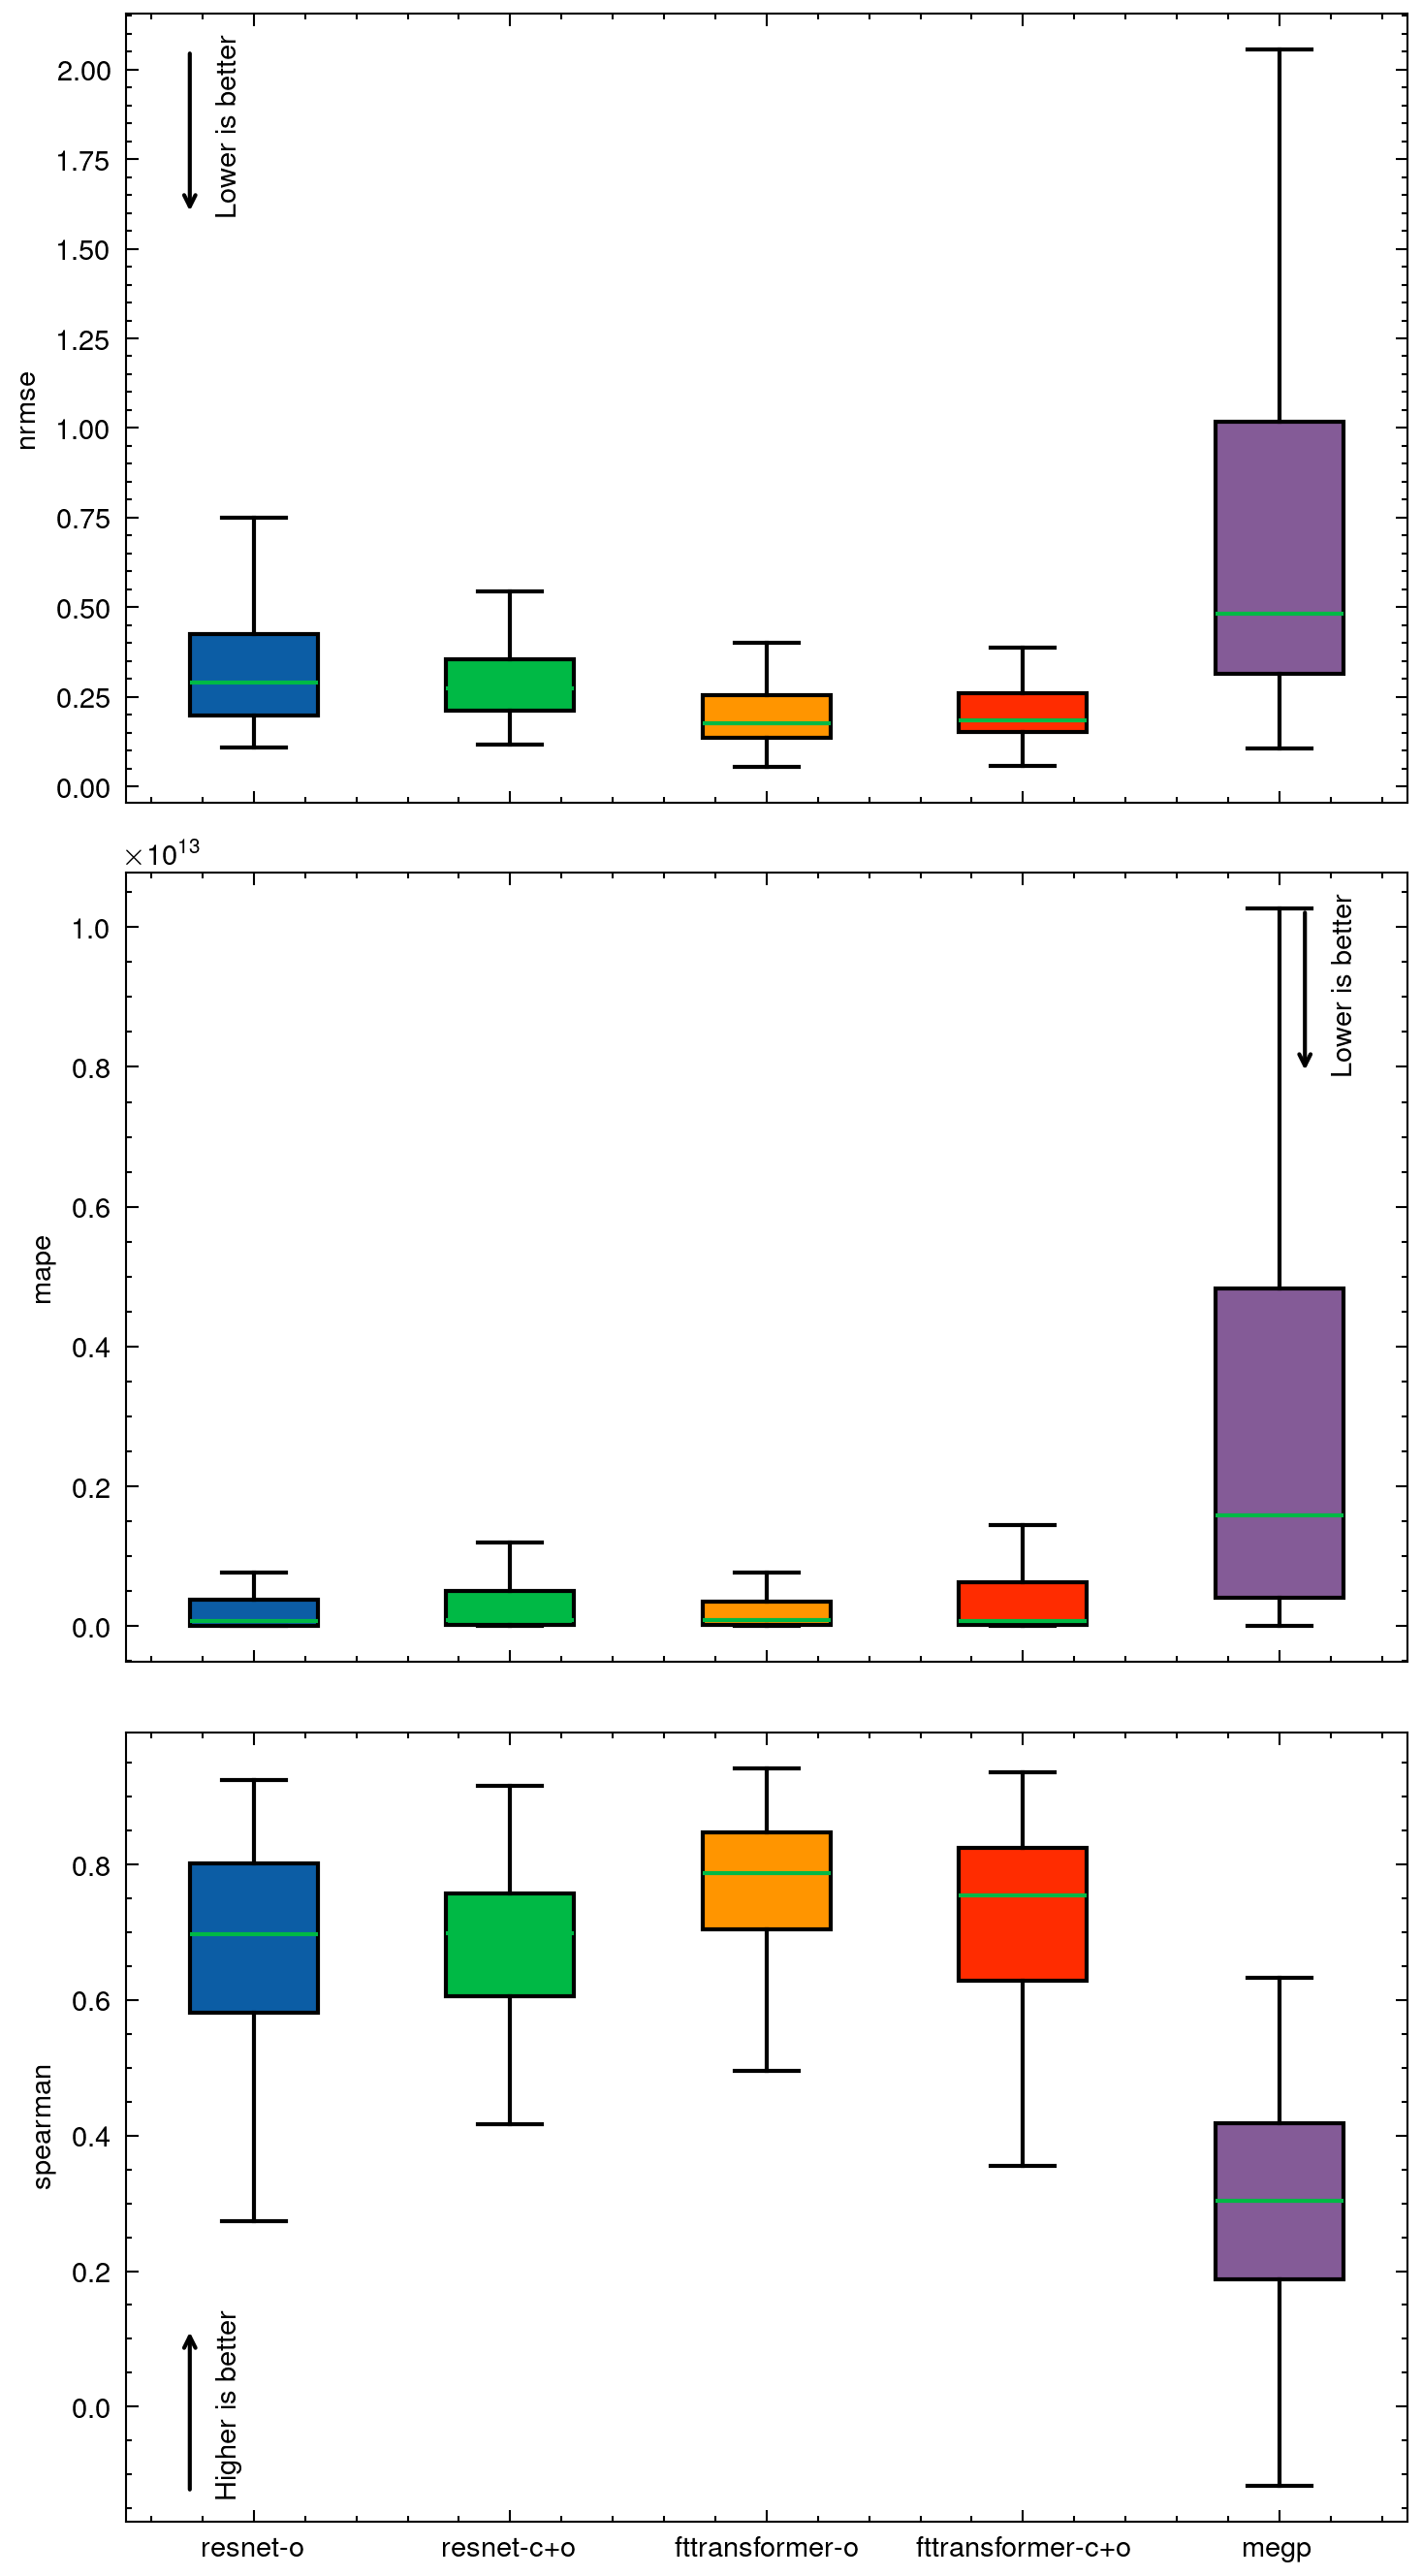

In [8]:
fig, axs = plt.subplots(len(prediction_summary), 1, figsize=(5, 3* len(prediction_summary)), sharex=True)

for i, (metric_name, model_dict) in enumerate(prediction_summary.items()):
    ax = axs[i]
    data = [model_dict[model] for model in model_dict]
    bplot = ax.boxplot(data, labels=list(model_dict.keys()), patch_artist=True, showfliers=False)
    #ax.set_title(metric)
    ax.set_ylabel(metric_name)

    for patch, color in zip(bplot['boxes'], icolors):
        patch.set_facecolor(color)

    if metric_name == 'spearman':
        lx = 0.05
        ly = 0.25
        ax.annotate(
            "",
            xy=(lx, ly),
            xytext=(lx, ly - 0.22),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="black"),
            annotation_clip=False,
        )
        ax.text(
            lx + 0.03,
            ly - 0.1,
            "Higher is better",
            rotation=90,
            va="center",
            ha="center",
            transform=ax.transAxes,
        )

    else:

        lx = 0.92 if metric_name == 'mape' else 0.05
        ly = 0.96 
        ax.annotate(
            "",
            xy=(lx, ly),
            xytext=(lx, ly - 0.22),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="<-", color="black"),
            annotation_clip=False,
        )
        ax.text(
            lx + 0.03,
            ly - 0.1,
            "Lower is better",
            rotation=90,
            va="center",
            ha="center",
            transform=ax.transAxes,
        )

ax.set_xticks(np.arange(1, len(model_dict) + 1))
#ax.set_xticklabels(list(model_dict.keys()), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [9]:
stash('figure2/prediction-metrics', fig)

## Timing

In [10]:
tt = {}
from uncertainties import ufloat

for p, d in timing_metrics.items():
    for model, dd in d.items():
        tt.setdefault(model, {})
        for v, ddd in dd.items():
            tt[model].setdefault(v, [])
            tt[model][v] += ddd
        for k in [kk for kk in tt[model].keys() if 'u' not in kk]:
            tt[model][f"{k}_mean"] = np.mean(tt[model][k])
            tt[model][f"{k}_std"] = np.std(tt[model][k])
            tt[model][f"{k}_u"] = ufloat(tt[model][f"{k}_mean"], tt[model][f"{k}_std"])

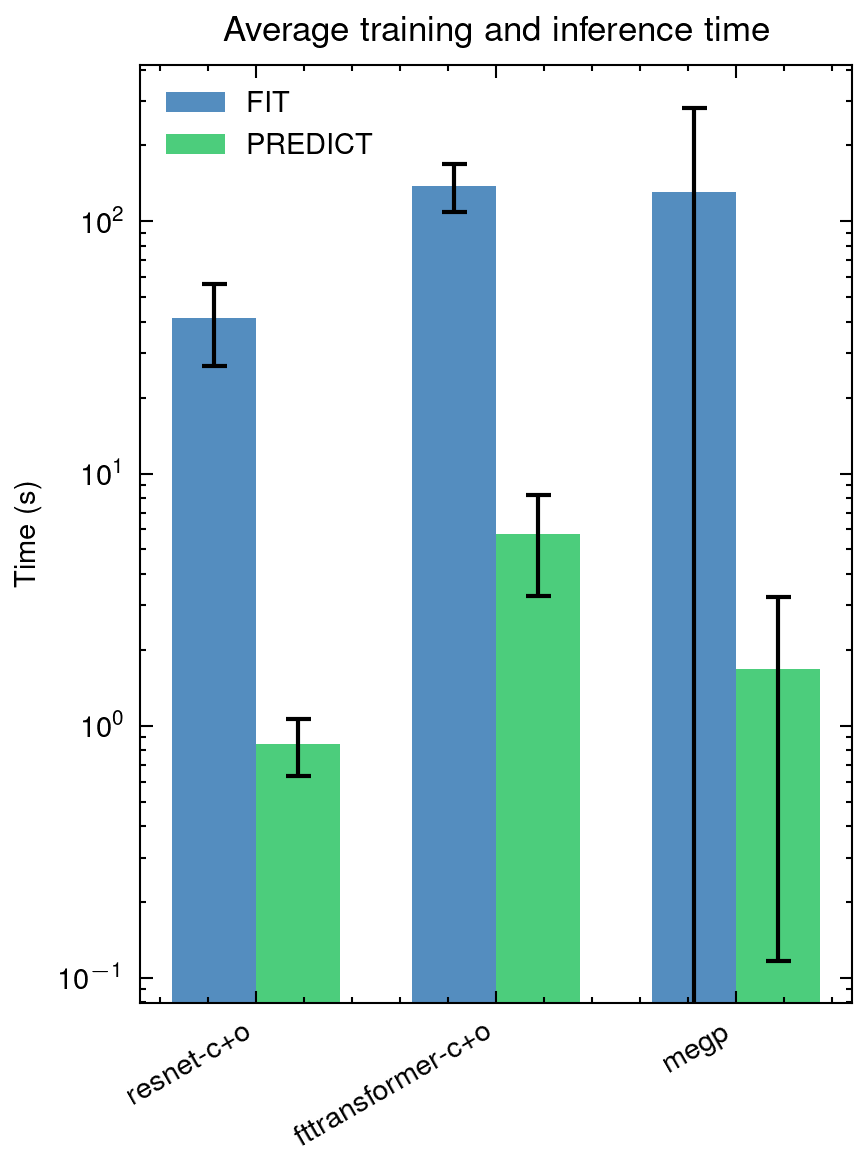

In [11]:
import numpy as np

models = ['resnet-c+o', 'fttransformer-c+o', 'megp']
modes = ['fit', 'predict']

import matplotlib.pyplot as plt


bar_width = 0.35
x = np.arange(len(models))

means = {mode: [tt[model][f"{mode}_mean"] for model in models] for mode in modes}
stds = {mode: [tt[model][f"{mode}_std"] for model in models] for mode in modes}

fig, ax = plt.subplots(figsize=(3, 4))

for i, mode in enumerate(modes):
    ax.bar(
        x + i * bar_width,
        means[mode],
        bar_width,
        yerr=stds[mode],
        label=mode.upper(),
        capsize=3,
        alpha=0.7,
    )

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel("Time (s)")
ax.set_yscale('log')
ax.set_title("Average training and inference time")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
stash('figure2/time-comparison', fig)

## Surrogate vs no-surrogate

In [2]:
nos_hv = restore("figure3-nos_hv")
baseline_hvs = restore("figure3-baseline_hvs")

In [3]:
from uncertainties import ufloat

def umean(a):
    return ufloat(np.mean(a), np.std(a))

final_performance = {}

for p in baseline_hvs.keys():

    final_performance[p] = {}

    for model in baseline_hvs[p].keys():
        final_performance[p][model] = umean(baseline_hvs[p][model]['24'])

final_performance

{'IVY': {'gpr': 1.4617665108651225+/-0.0005176928890737251,
  'megp': 1.4618410111000981+/-0.0011214639344736125,
  'o-resnet': 1.4622688554840855+/-0.001142544498182991,
  'c+o-resnet': 1.4629484364893568+/-0.0008033940540410945,
  'o-fttransformer': 1.4639698505558156+/-9.365371970593853e-05,
  'c+o-fttransformer': 1.4635882682509893+/-0.0005301733550357345,
  'baseline': 1.462375653073118+/-0.0005668753372955818},
 'PVBC': {'gpr': 1.463280519279263+/-0.0011326810477599182,
  'megp': 1.461610597492305+/-0.0020921995625662665,
  'o-resnet': 1.4617572390223375+/-0.001693425874938053,
  'c+o-resnet': 1.4631641942639524+/-0.0012506590579576483,
  'o-fttransformer': 1.4640989695303945+/-1.4217258254159049e-06,
  'c+o-fttransformer': 1.4641000000000004+/-4.796711693331816e-16,
  'baseline': 1.464078131810241+/-2.806941339566234e-05},
 'CCKBC': {'gpr': 1.4636761540107954+/-0.00010969176979106423,
  'megp': 1.463916963885761+/-0.00011276015754436377,
  'o-resnet': 1.4639935245482658+/-3.3141

In [4]:
_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

In [5]:
from models.utils import epsilon_indicator

epsilon_factors = {}

def _name(experiment):
    n = (
        experiment.label()
        .split("_neuron::")[-1][2:]
        .split("/")[0]
        .replace("joint-", "")
    )
    if "o" in n:
        n += (
            "-"
            + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        )
    return n

for p in _ca1_sopt_baseline.populations():
    experiments = _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    nadir = fronts_nadir(experiments)

    tracking = {}

    for experiment in experiments:
        model_name = _name(experiment)
        tracking.setdefault(model_name, [])
        tracking[model_name].append(experiment)


    baselines = tracking.pop('-')

    epsilon_factors[p] = {}
    for model_name, interfaces in tracking.items():
        eps = []
        for baseline, model in zip(baselines, interfaces):
            eps.append(
                epsilon_indicator(
                    model.norm_front(None, [[0.0] * len(nadir), nadir]),
                    baseline.norm_front(None, [[0.0] * len(nadir), nadir]),
                ) * 100 # percent
            )

        epsilon_factors[p][model_name] = eps


epsilon_factors

2025-07-23 22:49:26.172759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-23 22:49:26.193001: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-23 22:49:26.193036: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-23 22:49:26.206179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-23 22:49:27.313142: W tensorflow/compiler/tf

numprocs=1


{'IVY': {'gpr': [0.3578399479482248, 0.487963565383943, 0.5855562784607317],
  'megp': [0.5855562784607317, 0.6831489915375202, 0.6018217306401964],
  'o-resnet': [0.27651268705090104, 0.06506180871785906, 0.4391672088455487],
  'c+o-resnet': [0.22771633051250675,
   0.03253090435892953,
   0.16265452179464768],
  'o-fttransformer': [0.13012361743571813, 0.0, 0.016265452179464766],
  'c+o-fttransformer': [0.08132726089732384,
   0.016265452179464766,
   0.14638906961518292]},
 'PVBC': {'gpr': [0.6158224266118673, 0.6625881713941416, 0.19668603902549026],
  'megp': [0.8664553412683897, 1.2564827220503414, 0.935457885106761],
  'o-resnet': [0.934808842024671, 0.24338172743981756, 1.1847973201508502],
  'c+o-resnet': [0.6864996992963025, 0.00942603187516255, 0.661980287709331],
  'o-fttransformer': [0.002020881686190464, 0.09254452811051009, 0.0],
  'c+o-fttransformer': [0.0, 0.0, 0.0]},
 'CCKBC': {'gpr': [0.20086223789907814, 1.35459533607549, 0.9308250048981668],
  'megp': [0.8867332941

In [14]:
stash('figure2-epsilon_factors', epsilon_factors)

In [16]:
epsilon_factors = restore('figure2-epsilon_factors')

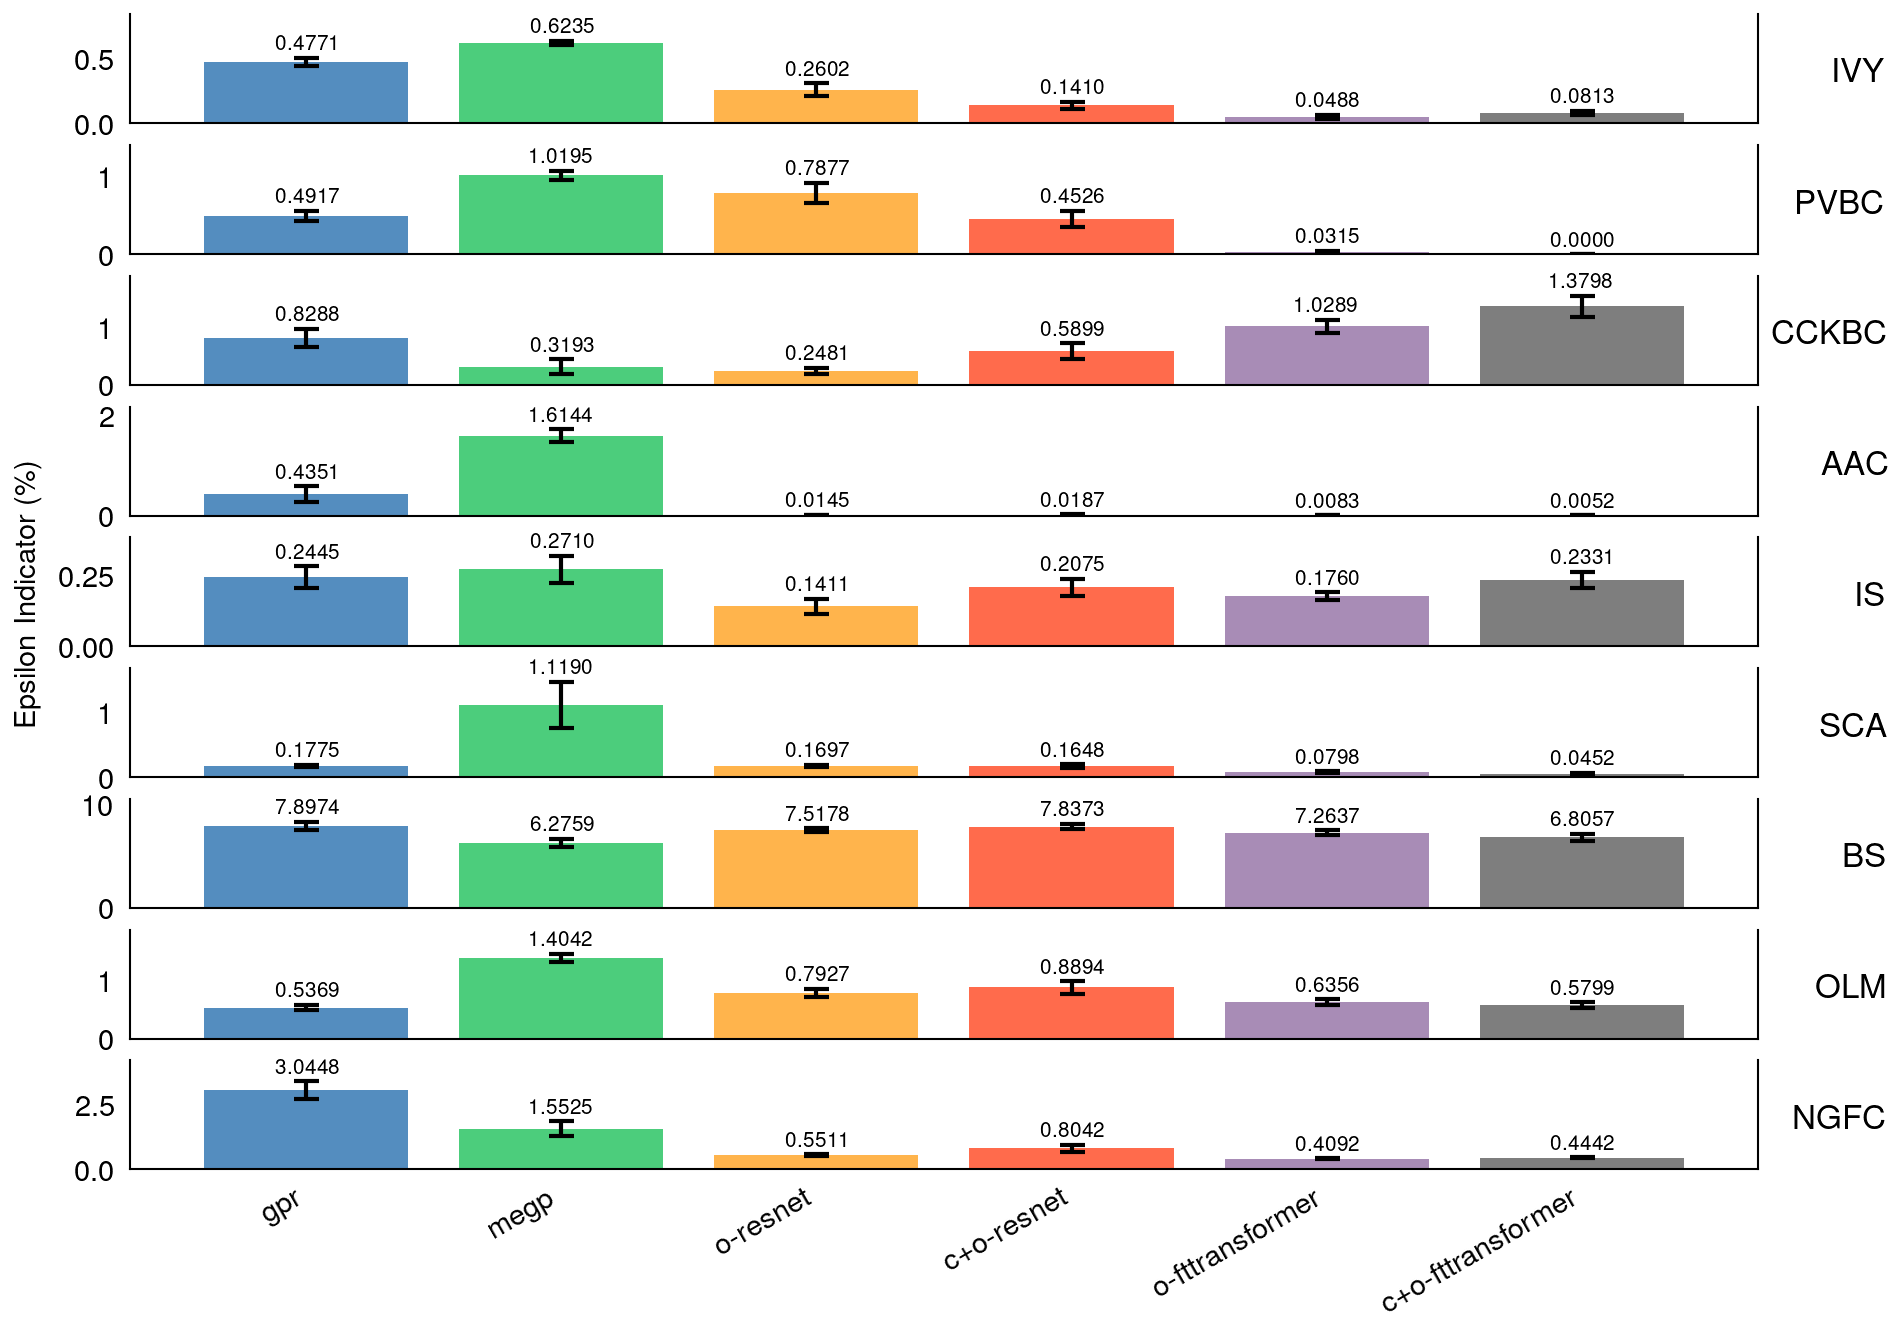

In [12]:
fig, axs = plt.subplots(len(_ca1_sopt_baseline.populations()), 1, figsize=(7, 5), sharex=True)

plt.rcParams["ytick.left"] = False
plt.rcParams["ytick.right"] = False
plt.rcParams["xtick.top"] = False
plt.rcParams["xtick.bottom"] = False


i = 0
for ax, (p, d) in zip(axs, epsilon_factors.items()):
    #label = f"{p} (HV={umean(nos_hv[p]).n:.2f})"
    label = p

    bar_width = 0.35
    x = np.arange(len(d))
    y = [np.mean(v) for v in d.values()]
    yerr= [np.std(v)/len(v) for v in d.values()]
    barc = ax.bar(
        x,
        y,
        #bar_width,
        yerr=yerr,
        #label=label,
        capsize=3,
        alpha=0.7,
        color=icolors
    )
    ax.bar_label(barc, label_type='edge', fmt='%.4f', color='black', rotation=0, fontsize=5, padding=1)

    ax.set_ylim([0, (np.max(y)+np.max(yerr)/2)*1.3])
    #ax.set_yscale('log')

    #ax.legend(loc='upper right')

    ax.text(
        1.08, 0.6, label,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment='top',
        horizontalalignment='right',
        #bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.3', alpha=0.8)
    )

    # ax.yaxis.set_label_coords(-0.08, 0.5)
    # ax.set_ylabel(label, rotation=0, va='center')

    i+=1

ax.set_xticks(x)
ax.set_xticklabels(list(d.keys()), rotation=30, ha='right')


axs[4].set_ylabel('Epsilon Indicator (\\%)')

plt.show()

In [13]:
stash('figure2/epsilon-performance', fig)

In [28]:
# sample difference
baseline = _ca1_sopt_baseline.components.first(
        lambda x: 'SCA' in x.label() and x.mO == '-' and not x.load_attribute("preflight", False)
    )
sopt = _ca1_sopt_baseline.components.first(
        lambda x: 'SCA' in x.label() and x.mO == 'gpr' and not x.load_attribute("preflight", False)
    )

print(baseline.num_evals_total)
print(sopt.num_evals_total)
print(baseline.num_evals_total / sopt.num_evals_total)


27900
3900
7.153846153846154


## Online accuracy

In [ ]:
surrogate_accuracy = {"data": {}}

_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

for p in _ca1_sopt_baseline.populations():
    experiments = _ca1_sopt_baseline.components.filter(lambda x: x.cached() and p in x.label())

    yy = []
    for experiment in experiments:
        h5 = experiment.load_h5()
        yy.append(h5["predictions"].to_numpy()[experiment.num_initial_samples :])
        yy.append(h5["objectives"].to_numpy()[experiment.num_initial_samples :])
    if len(yy) == 0:
        continue
    yy = np.vstack(yy)
    yy = yy[~np.isnan(yy)]
    yy_mean = np.mean(yy, axis=0)
    yy_std = np.std(yy, axis=0)

    def norm(y):
        return (y - yy_mean) / (yy_std + 1e-9)

    for experiment in experiments:
        label = experiment.label()
        cell_type, model_type = label.split("_neuron::")
        cell_type = cell_type.replace("CA1_", "")
        sampler_name = model_type[2:].split("/")[0].replace("joint-", "")
        trial = experiment.context.predicate.trial

        surrogate_accuracy["n_initial"] = n_initial = experiment.num_initial_samples
        surrogate_accuracy["data"].setdefault(cell_type, {})
        surrogate_accuracy["data"][cell_type].setdefault(sampler_name, {})

        h5 = experiment.load_h5()
        y_pred = norm(h5["predictions"].to_numpy()[n_initial:])
        y = norm(h5["objectives"].to_numpy()[n_initial:])

        nmae = np.abs(y - y_pred)

        N = int(experiment.num_evals_per_epoch * (experiment.num_evals_per_epoch - 1))
        nmae = np.pad(nmae, ((0, N - nmae.shape[0]), (0, 0)), constant_values=np.nan)

        # average in chunks of a 100
        surrogate_accuracy["chunk_size"] = chunk_size = 100
        start = 0  # experiment.num_initial_samples
        surrogate_accuracy["num"] = num = len(nmae) - start
        cutoff = num - (num % chunk_size)
        end = start + cutoff
        surrogate_accuracy["num_"] = end
        d = surrogate_accuracy["data"][cell_type][sampler_name]
        for i, col in enumerate(h5["objectives"].columns):
            d.setdefault(col, [])
            reduce = np.nanmean(nmae[start:end, i].reshape(-1, chunk_size), axis=1)
            d[col].append(reduce)

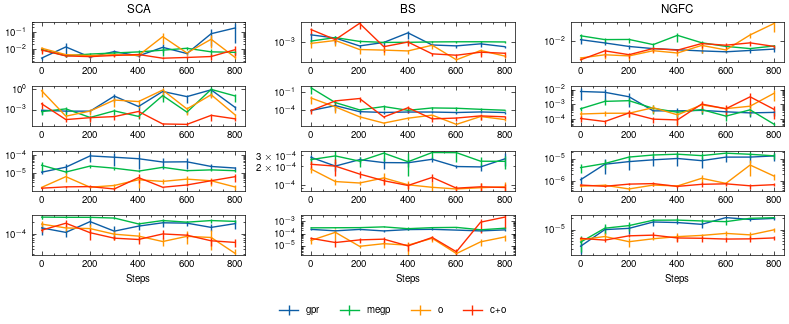

In [ ]:
fig, axs = plt.subplots(
    4, len(surrogate_accuracy["data"]), figsize=(8, 3), sharey=False
)

for ax, (cell_type, models) in zip(axs.T, surrogate_accuracy["data"].items()):
    for sampler_name, metric_name in models.items():
        c = 0
        for field, mm in metric_name.items():
            mm = np.array(mm)
            x = np.arange(
                0, surrogate_accuracy["num_"], surrogate_accuracy["chunk_size"]
            )
            y = mm.mean(axis=0)
            y_err = mm.std(axis=0) / np.sqrt(len(mm))

            ax[c].errorbar(x, y, yerr=y_err, label=sampler_name)
            ax[c].set_yscale("log")
            c += 1

    ax[-1].set_xlabel("Steps")
    # ax.set_ylim(0, 100)
    ax[0].set_title(cell_type)

# axs[0].set_ylabel('Normalized Mean Absolute Error')

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()

stash("figure2/single-cells-surrogate-accuracy", fig)